# 🚗 Dataset 1: Used Car Price Prediction
## Kỹ thuật: RobustScaler + IQR Outlier Detection + Feature Engineering

**Pipeline:** EDA → Phân tích Outliers → Feature Derivation → Preprocessing → Training → Evaluation

---

## 📦 0. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings, os
from datetime import datetime

import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
sns.set_theme(style='whitegrid', palette='husl')

SAVE_DIR = '../results/used_car'
os.makedirs(SAVE_DIR, exist_ok=True)
DATA_PATH = '../data/used_car_price/Car details v3.csv'
print('Libraries loaded successfully')

✅ Libraries loaded successfully


## 📂 1. Load Data & Tổng quan ban đầu

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (8128, 13)
Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
print('=== DATA TYPES & NULL VALUES ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
display(info)
print(f'\nDuplicated rows: {df.duplicated().sum()}')

=== DATA TYPES & NULL VALUES ===


,dtype,null_count,null_%,unique
name,object,0,0.00,2058
year,int64,0,0.00,29
selling_price,int64,0,0.00,677
km_driven,int64,0,0.00,921
fuel,object,0,0.00,4
seller_type,object,0,0.00,3
transmission,object,0,0.00,2
owner,object,0,0.00,5
mileage,object,221,2.72,393
engine,object,221,2.72,121



Duplicated rows: 1202


In [4]:
print('=== THỐNG KÊ MÔ TẢ ===')
df.describe().round(2)

=== THỐNG KÊ MÔ TẢ ===


,year,selling_price,km_driven,seats
count,8128.00,8128.00,8128.00,7907.00
mean,2013.80,638271.81,69819.51,5.42
std,4.04,806253.40,56550.55,0.96
min,1983.00,29999.00,1.00,2.00
25%,2011.00,254999.00,35000.00,5.00
50%,2015.00,450000.00,60000.00,5.00
75%,2017.00,675000.00,98000.00,5.00
max,2020.00,10000000.00,2360457.00,14.00


## 📊 2. Exploratory Data Analysis (EDA)

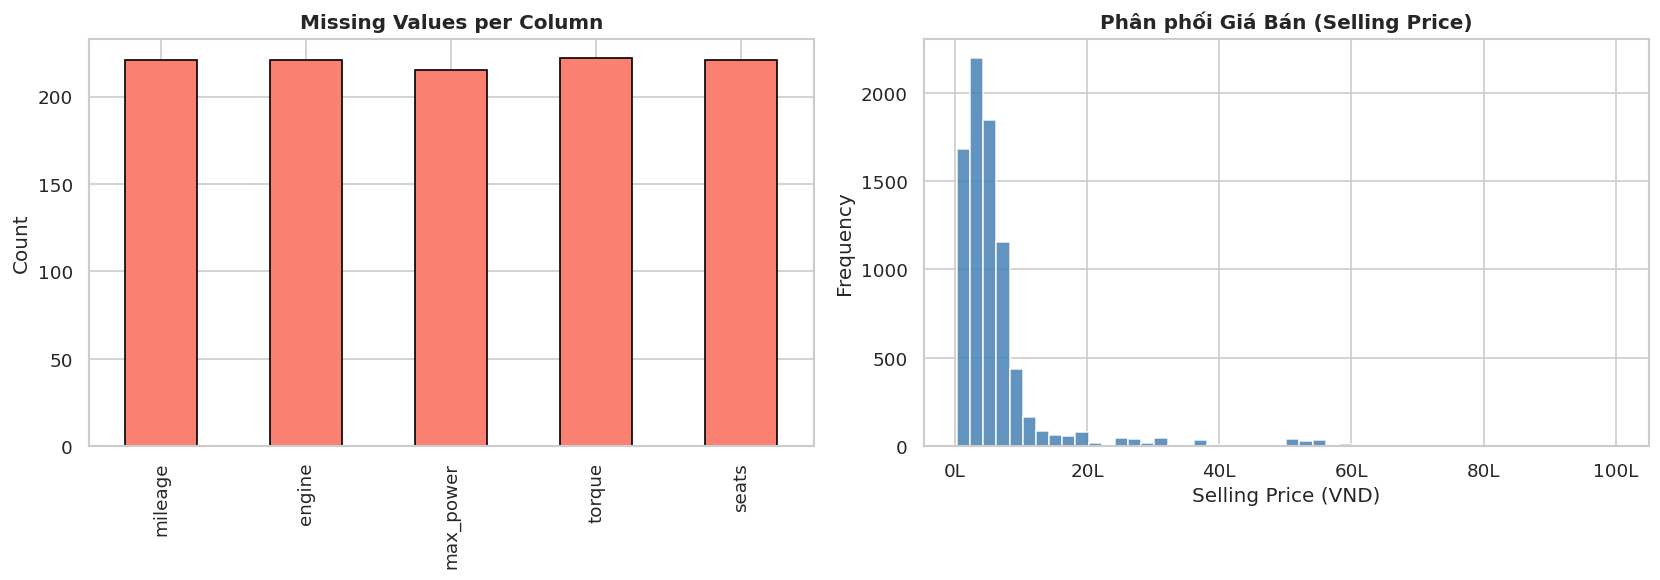

In [5]:
# Missing data heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values bar
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    missing.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
    axes[0].set_title('Missing Values per Column')
    axes[0].set_ylabel('Count')
else:
    axes[0].text(0.5, 0.5, 'No missing values!', ha='center', va='center',
                 fontsize=16, color='green', transform=axes[0].transAxes)
    axes[0].set_title('Missing Values')

# Selling price distribution
axes[1].hist(df['selling_price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối Giá Bán (Selling Price)')
axes[1].set_xlabel('Selling Price (VND)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_missing_and_price_dist.png', bbox_inches='tight')
plt.show()

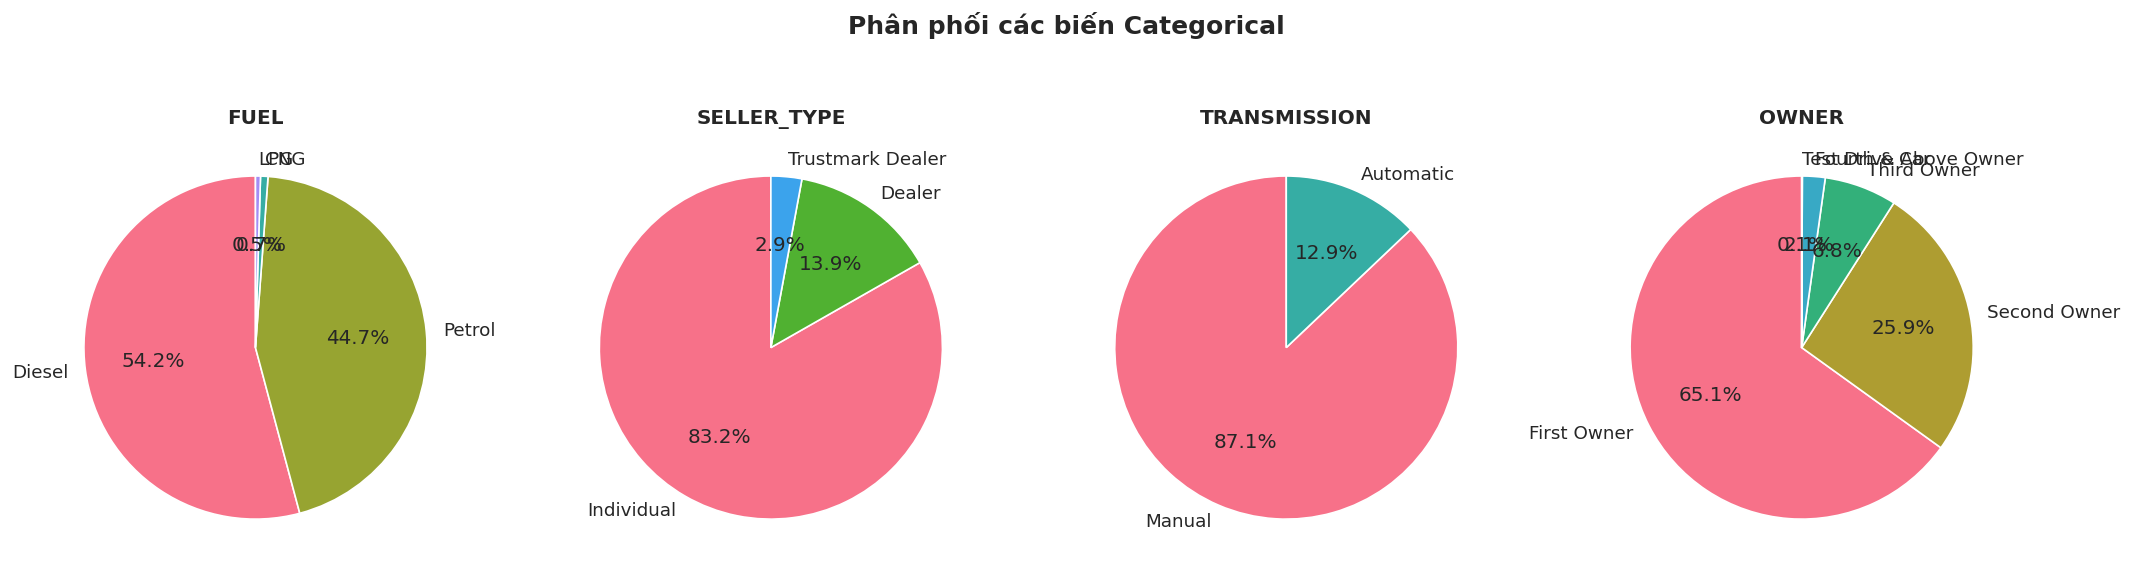

In [6]:
# Categorical columns analysis
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
for i, (col, ax, color) in enumerate(zip(cat_cols, axes, colors)):
    counts = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts.values, labels=counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('husl', len(counts))
    )
    ax.set_title(f'{col.upper()}')

plt.suptitle('Phân phối các biến Categorical', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_categorical_distribution.png', bbox_inches='tight')
plt.show()

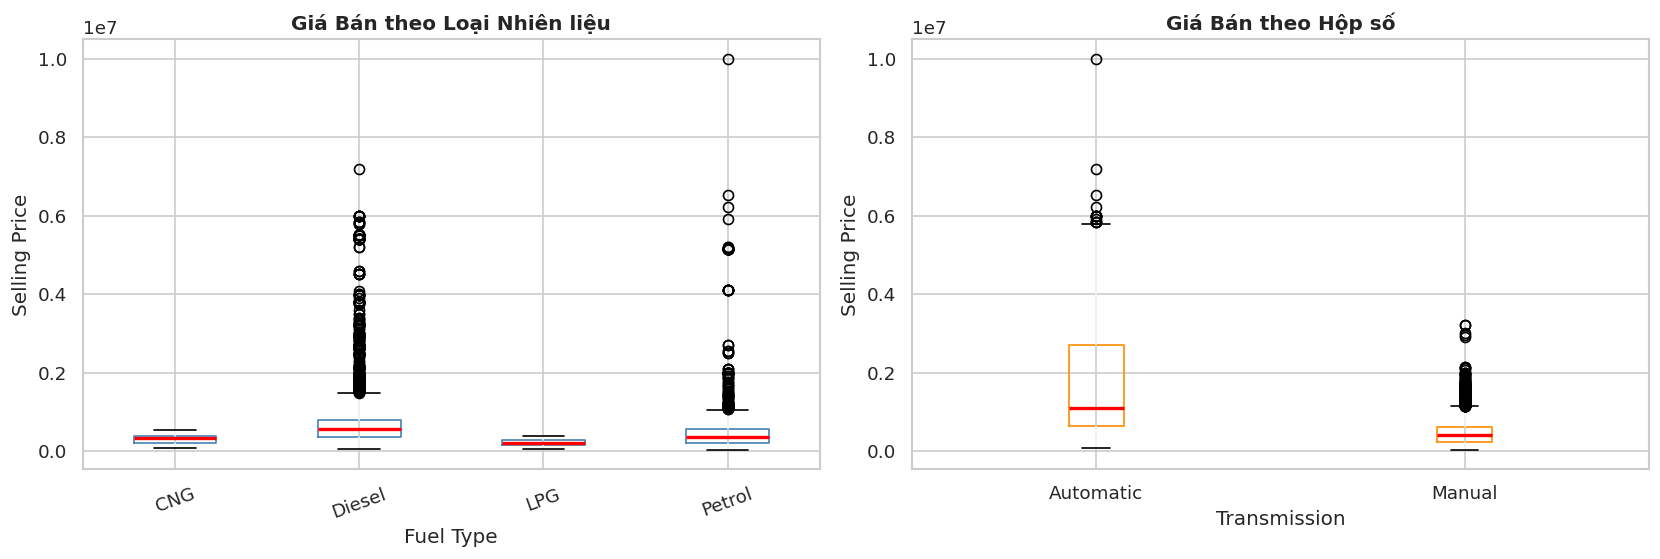

In [7]:
# Price by fuel type and transmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='selling_price', by='fuel', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Giá Bán theo Loại Nhiên liệu')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Selling Price')
plt.sca(axes[0])
plt.xticks(rotation=20)

df.boxplot(column='selling_price', by='transmission', ax=axes[1],
           boxprops=dict(color='darkorange'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Giá Bán theo Hộp số')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Selling Price')

plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_price_by_category.png', bbox_inches='tight')
plt.show()

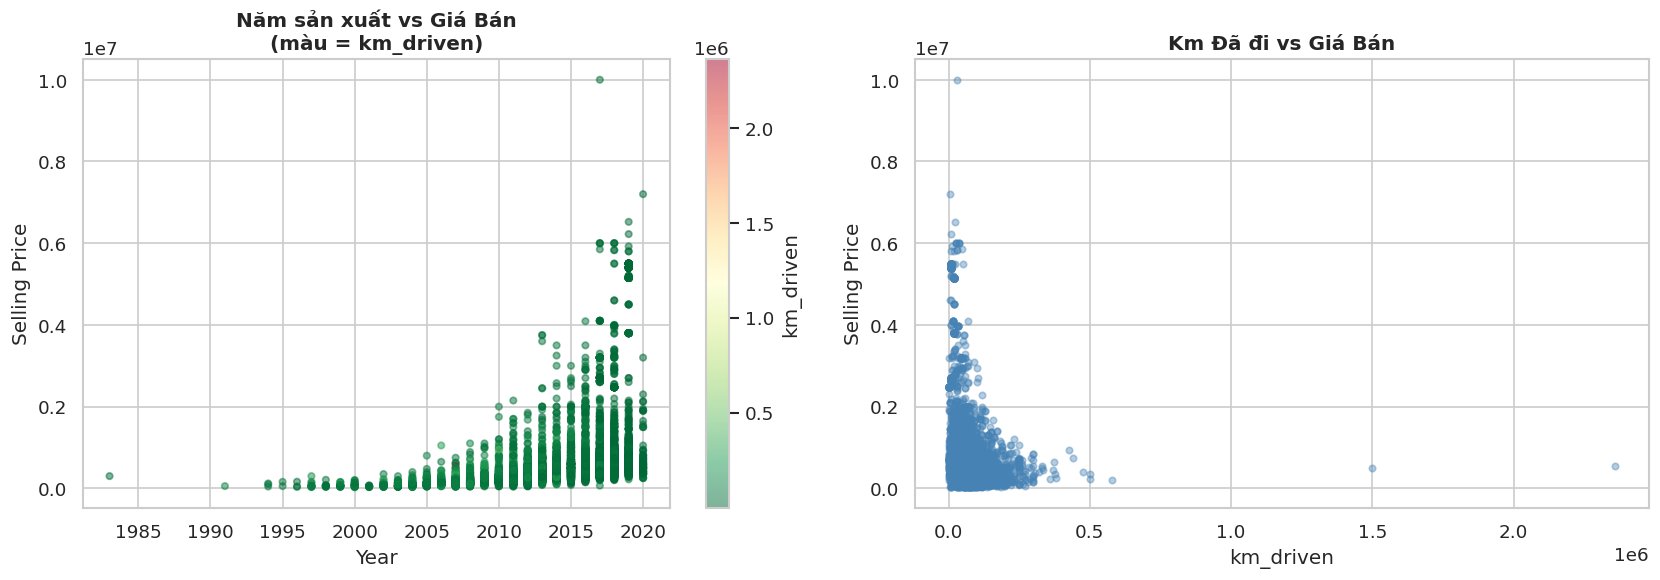

In [8]:
# Year vs Price scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(df['year'], df['selling_price'],
                     c=df['km_driven'], cmap='RdYlGn_r',
                     alpha=0.5, s=15)
plt.colorbar(sc, ax=axes[0], label='km_driven')
axes[0].set_title('Năm sản xuất vs Giá Bán\n(màu = km_driven)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Selling Price')

axes[1].scatter(df['km_driven'], df['selling_price'],
                alpha=0.4, s=15, color='steelblue')
axes[1].set_title('Km Đã đi vs Giá Bán')
axes[1].set_xlabel('km_driven')
axes[1].set_ylabel('Selling Price')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_scatter_year_km_price.png', bbox_inches='tight')
plt.show()

## 🔧 3. Feature Engineering & Outlier Detection

In [9]:
df_clean = df.copy()
current_year = datetime.now().year

# Feature Derivation
df_clean['car_age'] = current_year - df_clean['year']
df_clean['km_per_year'] = df_clean['km_driven'] / (df_clean['car_age'] + 1)

print('✅ New features created:')
print(df_clean[['year', 'km_driven', 'car_age', 'km_per_year']].describe().round(2))

✅ New features created:
          year   km_driven  car_age  km_per_year
count  8128.00     8128.00  8128.00      8128.00
mean   2013.80    69819.51    12.20      5137.48
std       4.04    56550.55     4.04      3549.37
min    1983.00        1.00     6.00         0.06
25%    2011.00    35000.00     9.00      2888.89
50%    2015.00    60000.00    11.00      4666.67
75%    2017.00    98000.00    15.00      6666.67
max    2020.00  2360457.00    43.00    118022.85


In [10]:
# IQR Outlier Detection
def detect_outliers_iqr(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    print(f'  {col_name}: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f} → Outliers={outliers} ({outliers/len(series)*100:.1f}%)')
    return lower, upper

print('=== IQR OUTLIER ANALYSIS ===')
for col in ['selling_price', 'km_driven', 'km_per_year']:
    detect_outliers_iqr(df_clean[col], col)

=== IQR OUTLIER ANALYSIS ===
  selling_price: Q1=254999, Q3=675000, IQR=420001 → Outliers=600 (7.4%)
  km_driven: Q1=35000, Q3=98000, IQR=63000 → Outliers=170 (2.1%)
  km_per_year: Q1=2889, Q3=6667, IQR=3778 → Outliers=225 (2.8%)


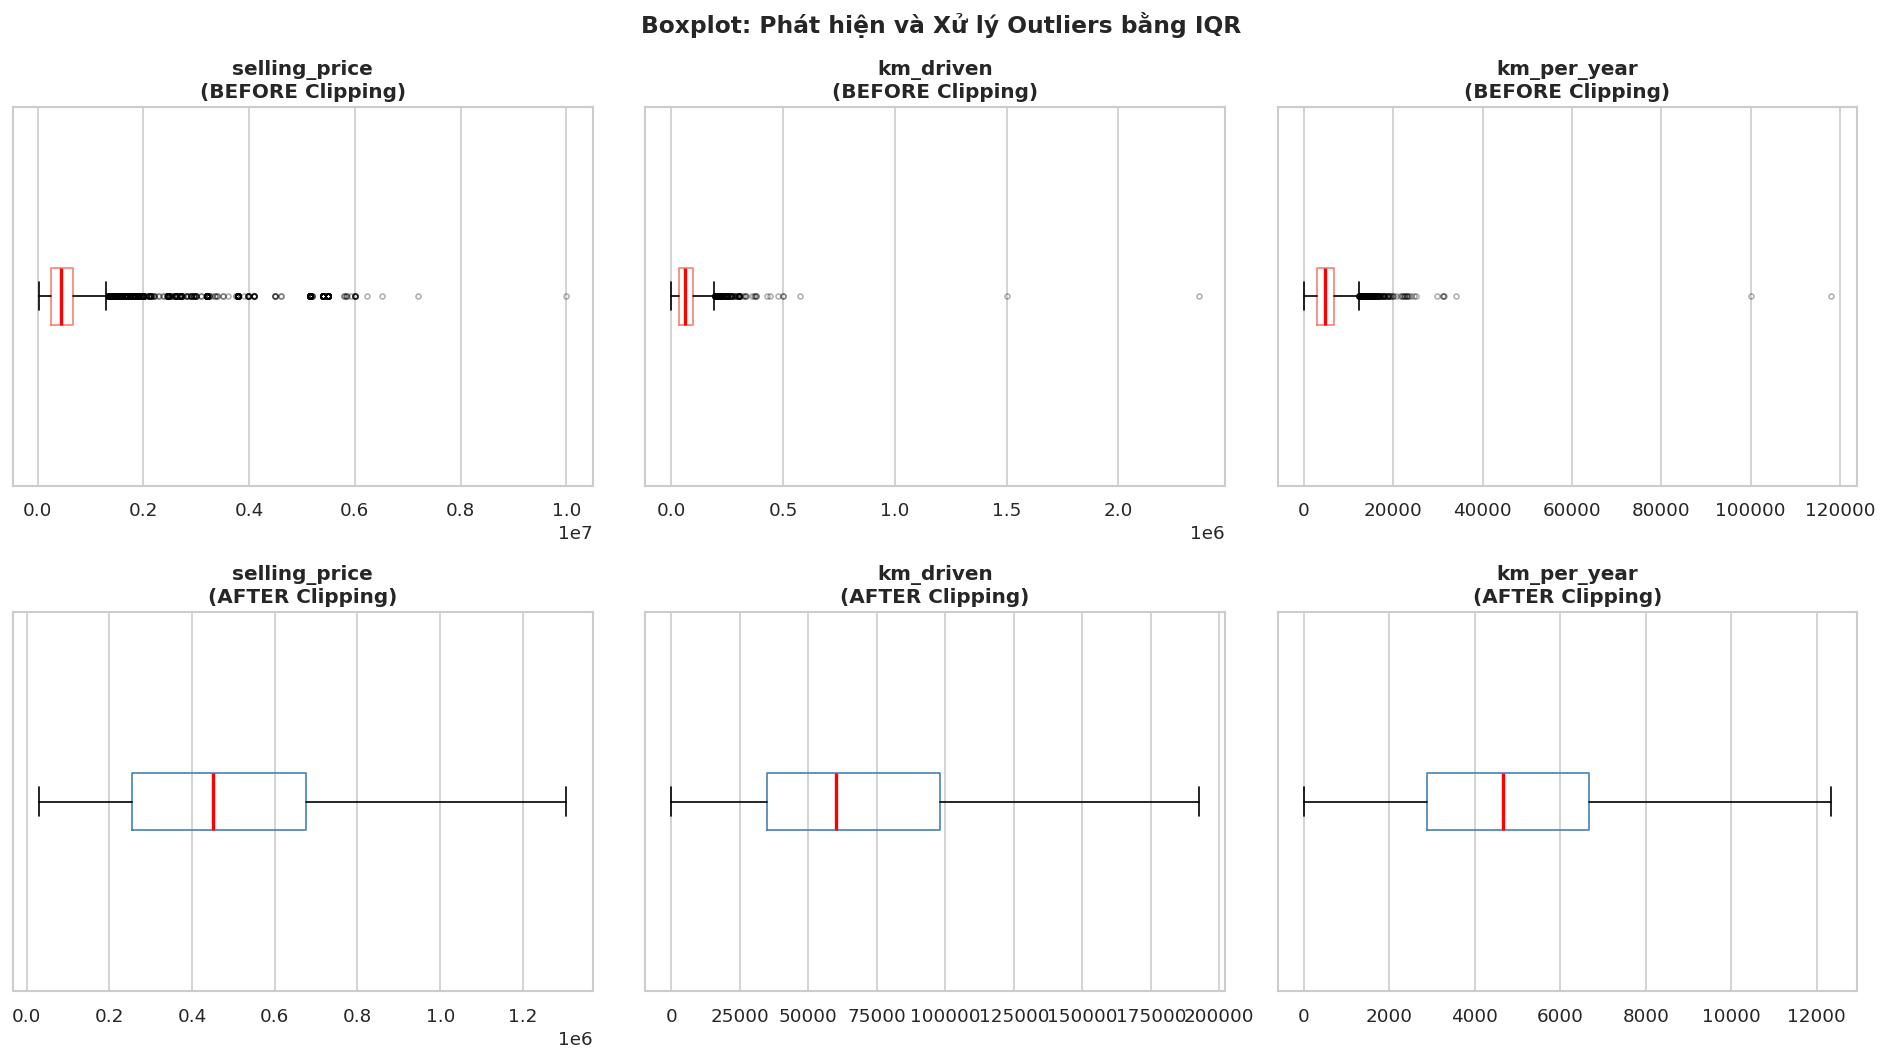

✅ Data shape after IQR clipping: (8128, 15)


In [11]:
# Boxplot Before vs After IQR clipping
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
numeric_cols = ['selling_price', 'km_driven', 'km_per_year']

# Before
for i, col in enumerate(numeric_cols):
    axes[0, i].boxplot(df_clean[col].dropna(), vert=False,
                       boxprops=dict(color='salmon'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    axes[0, i].set_title(f'{col}\n(BEFORE Clipping)')
    axes[0, i].set_yticks([])

# Clip outliers
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# After
for i, col in enumerate(numeric_cols):
    axes[1, i].boxplot(df_clean[col].dropna(), vert=False,
                       boxprops=dict(color='steelblue'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col}\n(AFTER Clipping)')
    axes[1, i].set_yticks([])

plt.suptitle('Boxplot: Phát hiện và Xử lý Outliers bằng IQR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_outlier_boxplots.png', bbox_inches='tight')
plt.show()
print(f'✅ Data shape after IQR clipping: {df_clean.shape}')

## ⚙️ 4. Preprocessing

In [12]:
df_proc = df_clean.copy()
df_proc = df_proc.drop(['name', 'year', 'torque'], axis=1, errors='ignore')

def clean_numeric(val):
    if pd.isna(val) or val == '': return 0
    try: return float(str(val).split()[0])
    except: return 0

for col in ['mileage', 'engine', 'max_power']:
    df_proc[col] = df_proc[col].apply(clean_numeric)

df_proc = df_proc.fillna(0)

le = LabelEncoder()
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

print('=== PROCESSED DATA PREVIEW ===')
display(df_proc.head())
print(f'Shape: {df_proc.shape}')

=== PROCESSED DATA PREVIEW ===


,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age,km_per_year
0,450000.0,145500,1,1,1,0,23.40,1248.0,74.00,5.0,12,11192.307692
1,370000.0,120000,1,1,1,2,21.14,1498.0,103.52,5.0,12,9230.769231
2,158000.0,140000,3,1,1,4,17.70,1497.0,78.00,5.0,20,6666.666667
3,225000.0,127000,1,1,1,0,23.00,1396.0,90.00,5.0,16,7470.588235
4,130000.0,120000,3,1,1,0,16.10,1298.0,88.20,5.0,19,6000.000000


Shape: (8128, 12)


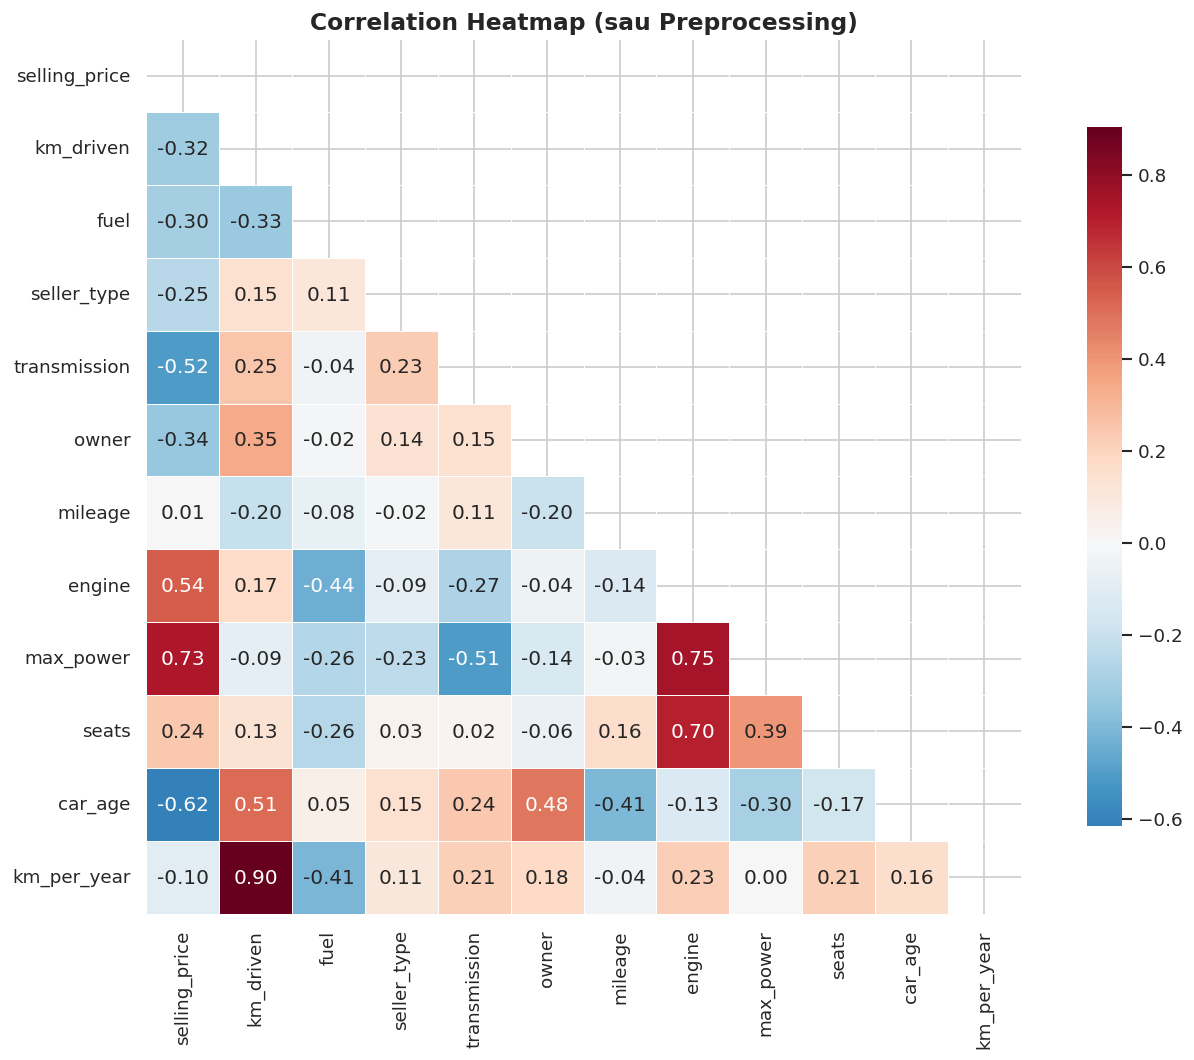

In [13]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_proc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap (sau Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [14]:
X = df_proc.drop('selling_price', axis=1)
y = df_proc['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size: {X_train_s.shape}, Test size: {X_test_s.shape}')

Train size: (6502, 11), Test size: (1626, 11)


## 🤖 5. Training — So sánh 3 Models

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    preds = mdl.predict(X_test_s)
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'model': mdl, 'preds': preds, 'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f'{name:25s} | R2={r2:.4f} | MAE={mae:,.0f} | RMSE={rmse:,.0f}')

Linear Regression         | R2=0.7943 | MAE=115,373 | RMSE=150,172
Ridge Regression          | R2=0.7945 | MAE=115,338 | RMSE=150,079
Random Forest             | R2=0.9326 | MAE=54,902 | RMSE=85,969


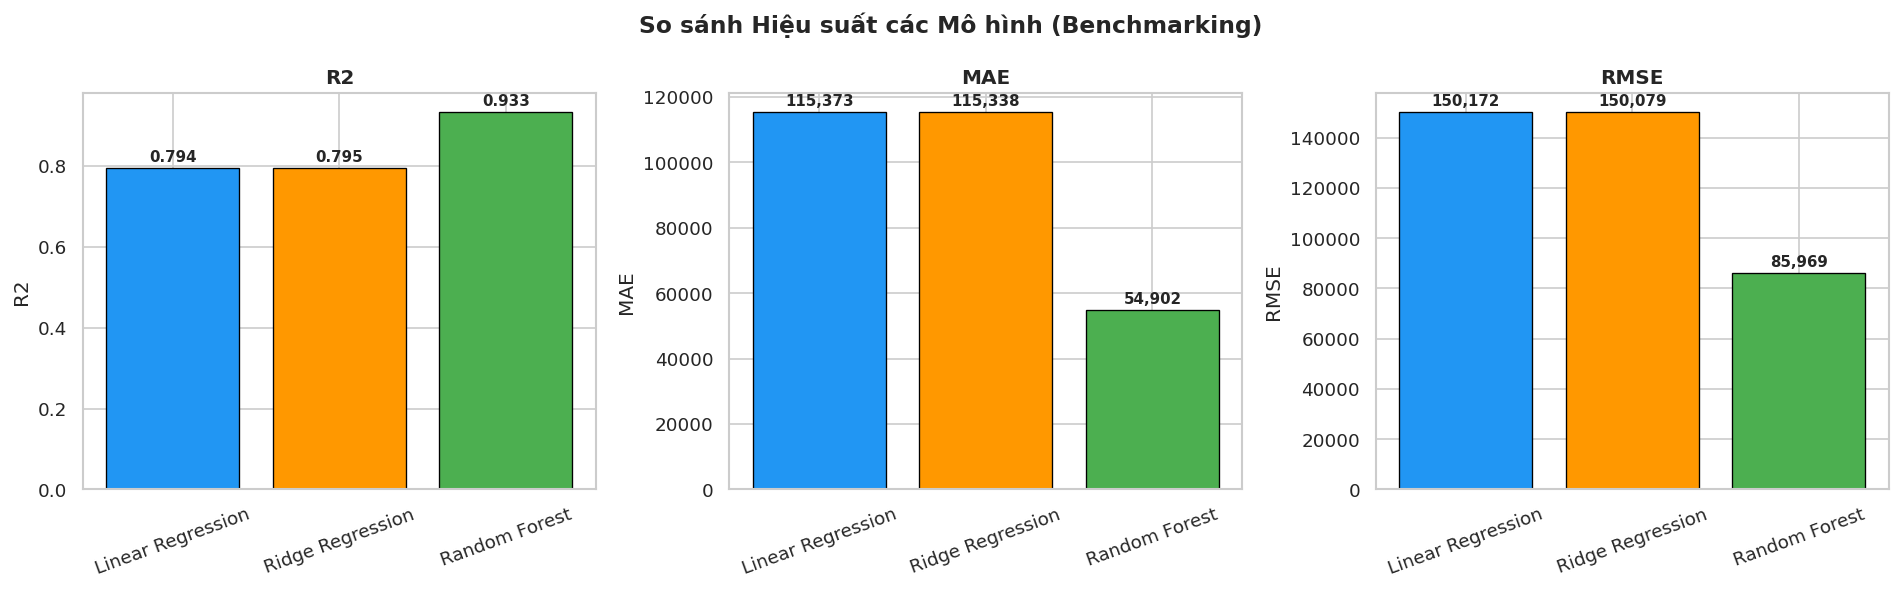

In [16]:
# Benchmarking Bar Chart
metrics = ['R2', 'MAE', 'RMSE']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, edgecolor='black', linewidth=0.8)
    ax.set_title(f'{metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}' if metric=='R2' else f'{val:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('So sánh Hiệu suất các Mô hình (Benchmarking)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_model_benchmarking.png', bbox_inches='tight')
plt.show()

Best model: Random Forest (R2=0.9326)


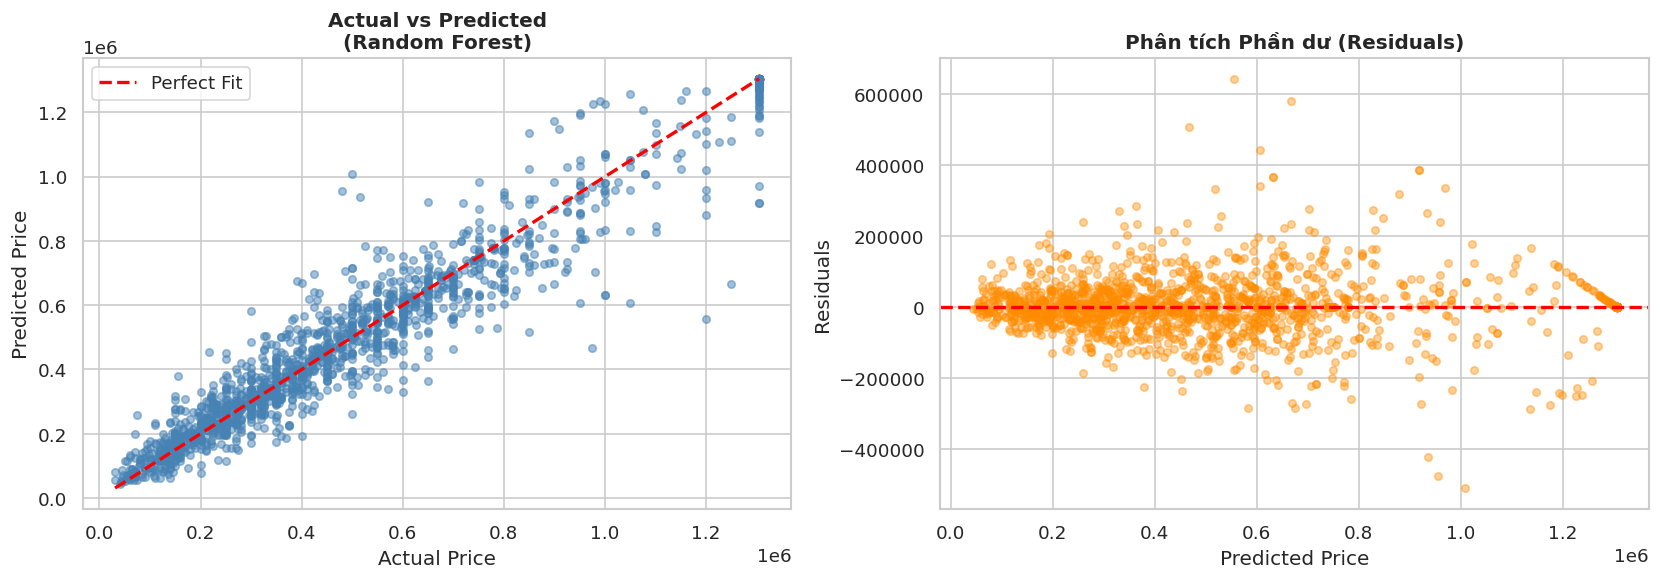

In [17]:
# Actual vs Predicted - Best Model
best_name = max(results, key=lambda m: results[m]['R2'])
best_preds = results[best_name]['preds']
print(f'Best model: {best_name} (R2={results[best_name]["R2"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.5, s=20, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Actual vs Predicted\n({best_name})')
axes[0].legend()

# Residuals
residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.4, s=20, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Phân tích Phần dư (Residuals)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_actual_vs_pred_residuals.png', bbox_inches='tight')
plt.show()

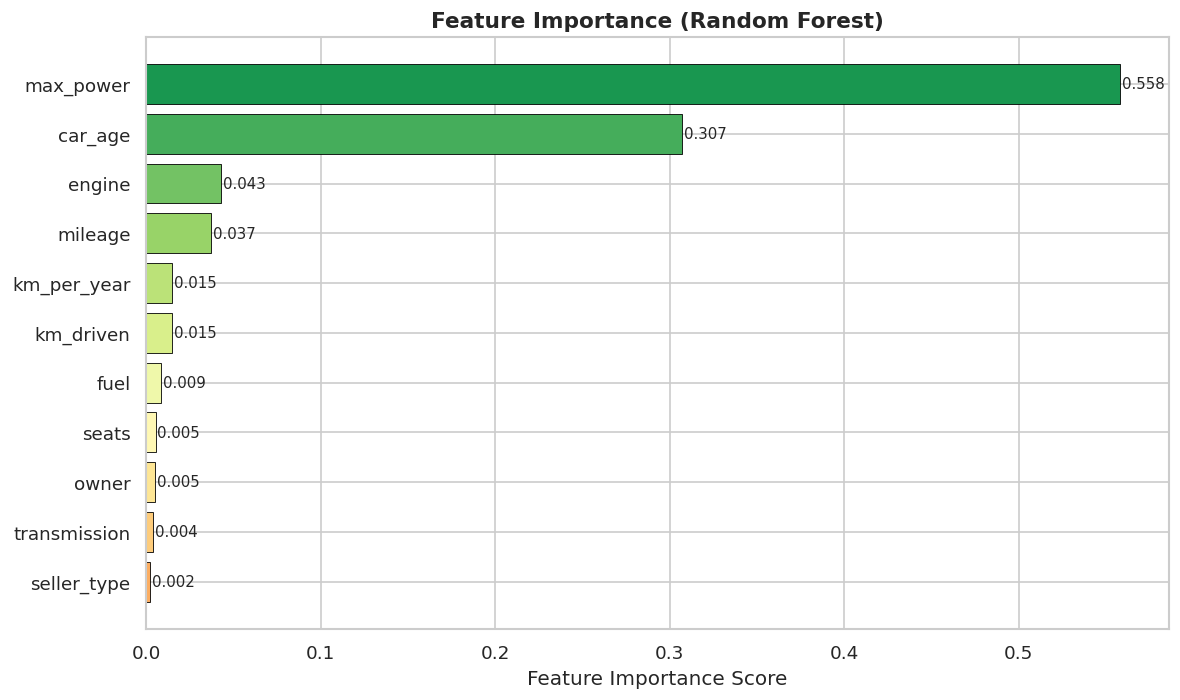

In [18]:
# Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
fi = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi)))
bars = ax.barh(fi.index, fi.values, color=colors_fi, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, fi.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/09_feature_importance.png', bbox_inches='tight')
plt.show()

## 📝 6. Lưu Báo cáo Kết quả

In [19]:
report_lines = ['Used Car Price Regression Report\n', '='*50 + '\n']
for name, res in results.items():
    report_lines.append(f'\n[{name}]\n')
    report_lines.append(f'  R2   : {res["R2"]:.4f}\n')
    report_lines.append(f'  MAE  : {res["MAE"]:,.2f}\n')
    report_lines.append(f'  RMSE : {res["RMSE"]:,.2f}\n')
report_lines.append(f'\nBest Model: {best_name} (R2={results[best_name]["R2"]:.4f})\n')

with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.writelines(report_lines)

print(''.join(report_lines))
print('✅ Experiment Completed! All results saved to', SAVE_DIR)

Used Car Price Regression Report

[Linear Regression]
  R2   : 0.7943
  MAE  : 115,372.51
  RMSE : 150,171.58

[Ridge Regression]
  R2   : 0.7945
  MAE  : 115,337.67
  RMSE : 150,078.95

[Random Forest]
  R2   : 0.9326
  MAE  : 54,902.10
  RMSE : 85,968.88

Best Model: Random Forest (R2=0.9326)

✅ Experiment Completed! All results saved to ../results/used_car
